## **YOLOv11n**

In [ ]:
!pip install -q ultralytics torchvision tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.0 MB/s eta 0:00:00


In [ ]:
import zipfile
import shutil
from pathlib import Path
from collections import defaultdict

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive
from ultralytics import YOLO
from google.colab import drive, files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


1. MOUNTING DRIVE

In [ ]:
drive.mount("/content/drive")

DRIVE_DIR     = Path("/content/drive/MyDrive/PPE_YOLO11")
DRIVE_RESULTS = DRIVE_DIR / "yolov11n_results"
METRICS_LOG   = DRIVE_DIR / "yolov11n_metrics_summary.txt"
DRIVE_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


2. EXTRACTING THE DATASET

In [ ]:
from google.colab import files

print("Select your dataset ZIP file to upload:")
uploaded = files.upload()

ZIP_PATH = Path(next(iter(uploaded)))
DATA_DIR = Path("/content/ppe_data")

if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

print("Extracting dataset...")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(DATA_DIR)
print(f"Extracted to: {DATA_DIR}")

Select your dataset ZIP file to upload:


Saving Roboflow.zip to Roboflow.zip
Extracting dataset...
Extracted to: /content/ppe_data


3. LOCATING data.yaml

In [ ]:
DATA_YAML = DATA_DIR / "results_yolov8n_100e" / "kaggle" / "working" / "ppe_data.yaml"

if not DATA_YAML.exists():
    raise FileNotFoundError(f"Expected data.yaml not found at {DATA_YAML}")

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

cfg["path"]  = str(DATA_DIR / "css-data")
cfg["train"] = "train/images"
cfg["val"]   = "valid/images"
cfg["test"]  = "test/images"

with open(DATA_YAML, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

CLASS_NAMES  = cfg["names"]
DATASET_ROOT = Path(cfg["path"])
print(f"data.yaml sanitized: {DATA_YAML}")
print(f"Classes: {CLASS_NAMES}")

data.yaml sanitized: /content/ppe_data/results_yolov8n_100e/kaggle/working/ppe_data.yaml
Classes: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


4. SANITY CHECKING

In [ ]:
def verify_split(split_name: str, img_subdir: str, lbl_subdir: str):
    img_dir = DATASET_ROOT / split_name / img_subdir
    lbl_dir = DATASET_ROOT / split_name / lbl_subdir

    if not img_dir.exists():
        raise RuntimeError(f"Missing image directory: {img_dir}")
    if not lbl_dir.exists():
        raise RuntimeError(f"Missing label directory: {lbl_dir}")

    images = list(img_dir.glob("*.[jp][pn]g")) + list(img_dir.glob("*.jpeg"))
    labels = list(lbl_dir.glob("*.txt"))

    if not images:
        raise RuntimeError(f"No images found in {img_dir}")
    if not labels:
        raise RuntimeError(f"No label files found in {lbl_dir}")

    print(f"  {split_name:<6}  {len(images):>5} images  {len(labels):>5} labels")

print("Verifying splits:")
for split in ("train", "valid", "test"):
    verify_split(split, "images", "labels")

Verifying splits:
  train    2605 images   2605 labels
  valid     114 images    114 labels
  test       82 images     82 labels


5. EDA (CLASS DISTRIBUTION)

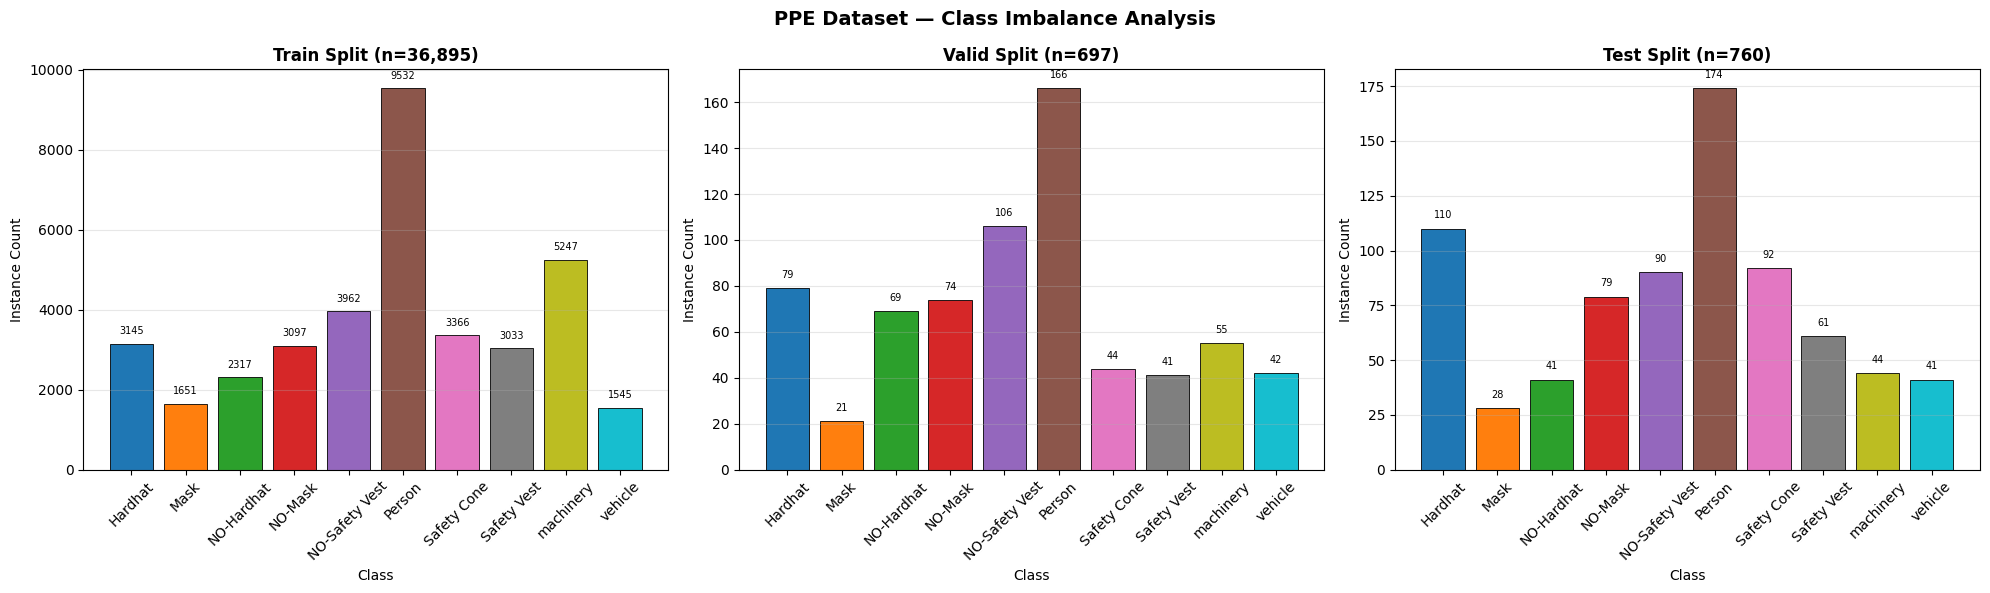

In [ ]:
def count_classes(split):
    counts = defaultdict(int)
    for f in (DATASET_ROOT / split / "labels").glob("*.txt"):
        for line in f.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                counts[int(parts[0])] += 1
    return counts

split_counts = {s: count_classes(s) for s in ("train", "valid", "test")}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
palette = plt.cm.tab10.colors

for ax, (split, counts) in zip(axes, split_counts.items()):
    vals  = [counts.get(i, 0) for i in range(len(CLASS_NAMES))]
    total = sum(vals)
    bars  = ax.bar(CLASS_NAMES, vals, color=palette[:len(CLASS_NAMES)],
                   edgecolor="black", linewidth=0.6)
    ax.set_title(f"{split.capitalize()} Split (n={total:,})", fontweight="bold")
    ax.set_xlabel("Class"); ax.set_ylabel("Instance Count")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+total*0.005,
                str(val), ha="center", va="bottom", fontsize=7)

plt.suptitle("PPE Dataset — Class Imbalance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(DRIVE_DIR / "eda_class_distribution_yolov11n.png", dpi=150, bbox_inches="tight")
plt.show()

6. TRAINING

In [ ]:
model = YOLO("yolo11n.pt")

try:
    model.train(
        data          = str(DATA_YAML),
        device        = 0,
        imgsz         = 640,
        epochs        = 50,
        patience      = 15,
        batch         = 16,
        lr0           = 1e-3,
        weight_decay  = 5e-4,
        warmup_epochs = 3,
        seed          = 42,
        cls_pw        = 1.0,
        cls           = 2.0,
        close_mosaic  = 10,
        project       = str(DRIVE_RESULTS),
        name          = "yolov11n_v1",
        exist_ok      = True,
    )

except RuntimeError as e:
    if "out of memory" in str(e).lower():
        torch.cuda.empty_cache()
        print(
            "\n[CUDA OOM] GPU memory exhausted.\n"
            "  Reduce batch to 8 or drop imgsz to 416 and retry.\n"
            "  Switch to an A100 runtime if the issue persists."
        )
    raise

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_data/results_yolov8n_100e/kaggle/working/ppe_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov11n_v1, nbs=64, nms=False, opset=None, optimize=False, optimiz

7. TRAINING CURVES

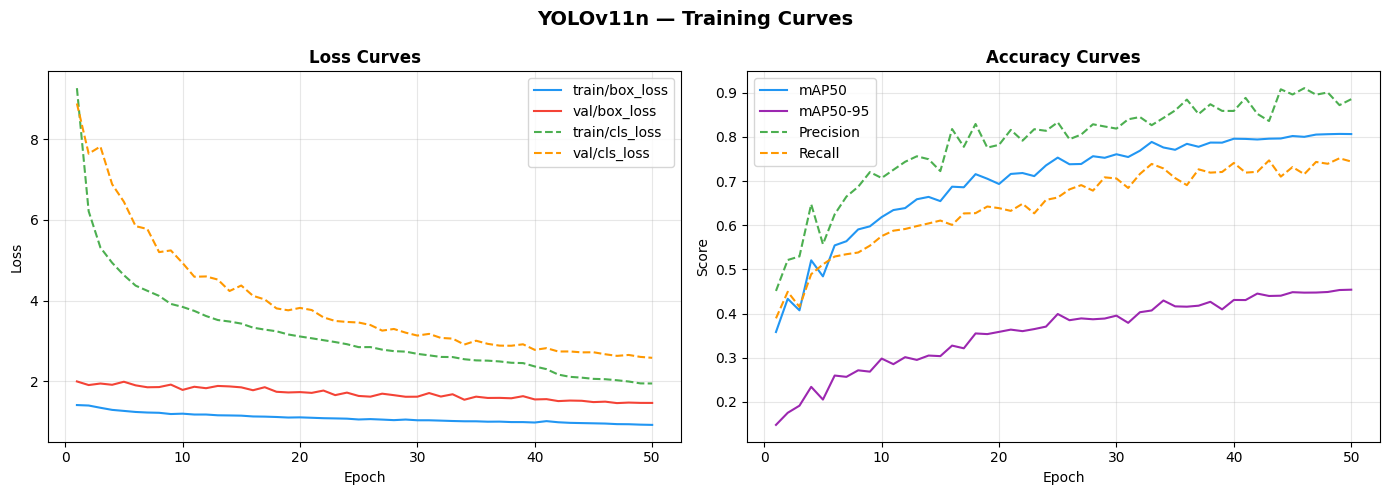

In [ ]:
RUN_DIR     = DRIVE_RESULTS / "yolov11n_v1"
results_csv = RUN_DIR / "results.csv"

if not results_csv.exists():
    raise FileNotFoundError(
        f"results.csv not found at {results_csv}. "
        "If the runtime disconnected mid-training, check "
        f"{DRIVE_RESULTS} for the actual run folder name "
        "(Ultralytics may have appended a suffix like yolov11n_v12)."
    )

df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df["epoch"], df["train/box_loss"], label="train/box_loss", color="#2196F3")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val/box_loss",   color="#F44336")
axes[0].plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss", color="#4CAF50", linestyle="--")
axes[0].plot(df["epoch"], df["val/cls_loss"],   label="val/cls_loss",   color="#FF9800", linestyle="--")
axes[0].set_title("Loss Curves", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df["epoch"], df["metrics/mAP50(B)"],    label="mAP50",    color="#2196F3")
axes[1].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95", color="#9C27B0")
axes[1].plot(df["epoch"], df["metrics/precision(B)"], label="Precision", color="#4CAF50", linestyle="--")
axes[1].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall",    color="#FF9800", linestyle="--")
axes[1].set_title("Accuracy Curves", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("YOLOv11n — Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(DRIVE_RESULTS / "training_curves_yolov11n.png", dpi=150, bbox_inches="tight")
plt.show()

8. EVALUATING ON TEST SPLIT

In [ ]:
print("\nEvaluating on test split...")
val_results = model.val(
    data   = str(DATA_YAML),
    split  = "test",
    imgsz  = 640,
    device = 0,
)

global_map50    = val_results.box.map50
global_map50_95 = val_results.box.map
per_class_ap50  = val_results.box.ap50
class_names     = model.names


Evaluating on test split...
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1140.7±302.8 MB/s, size: 49.3 KB)
val: Scanning /content/ppe_data/css-data/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 2.1Kit/s 0.0s
val: New cache created: /content/ppe_data/css-data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.8s
                   all         82        760      0.837      0.671      0.736      0.395
               Hardhat         30        110      0.955      0.809      0.882      0.499
                  Mask         16         28      0.921       0.75      0.772       0.46
            NO-Hardhat         25         41      0.857      0.583      0.609      0.266
               NO-Mask         30       

9. PER-CLASS AP CHART & CONFUSION MATRIX

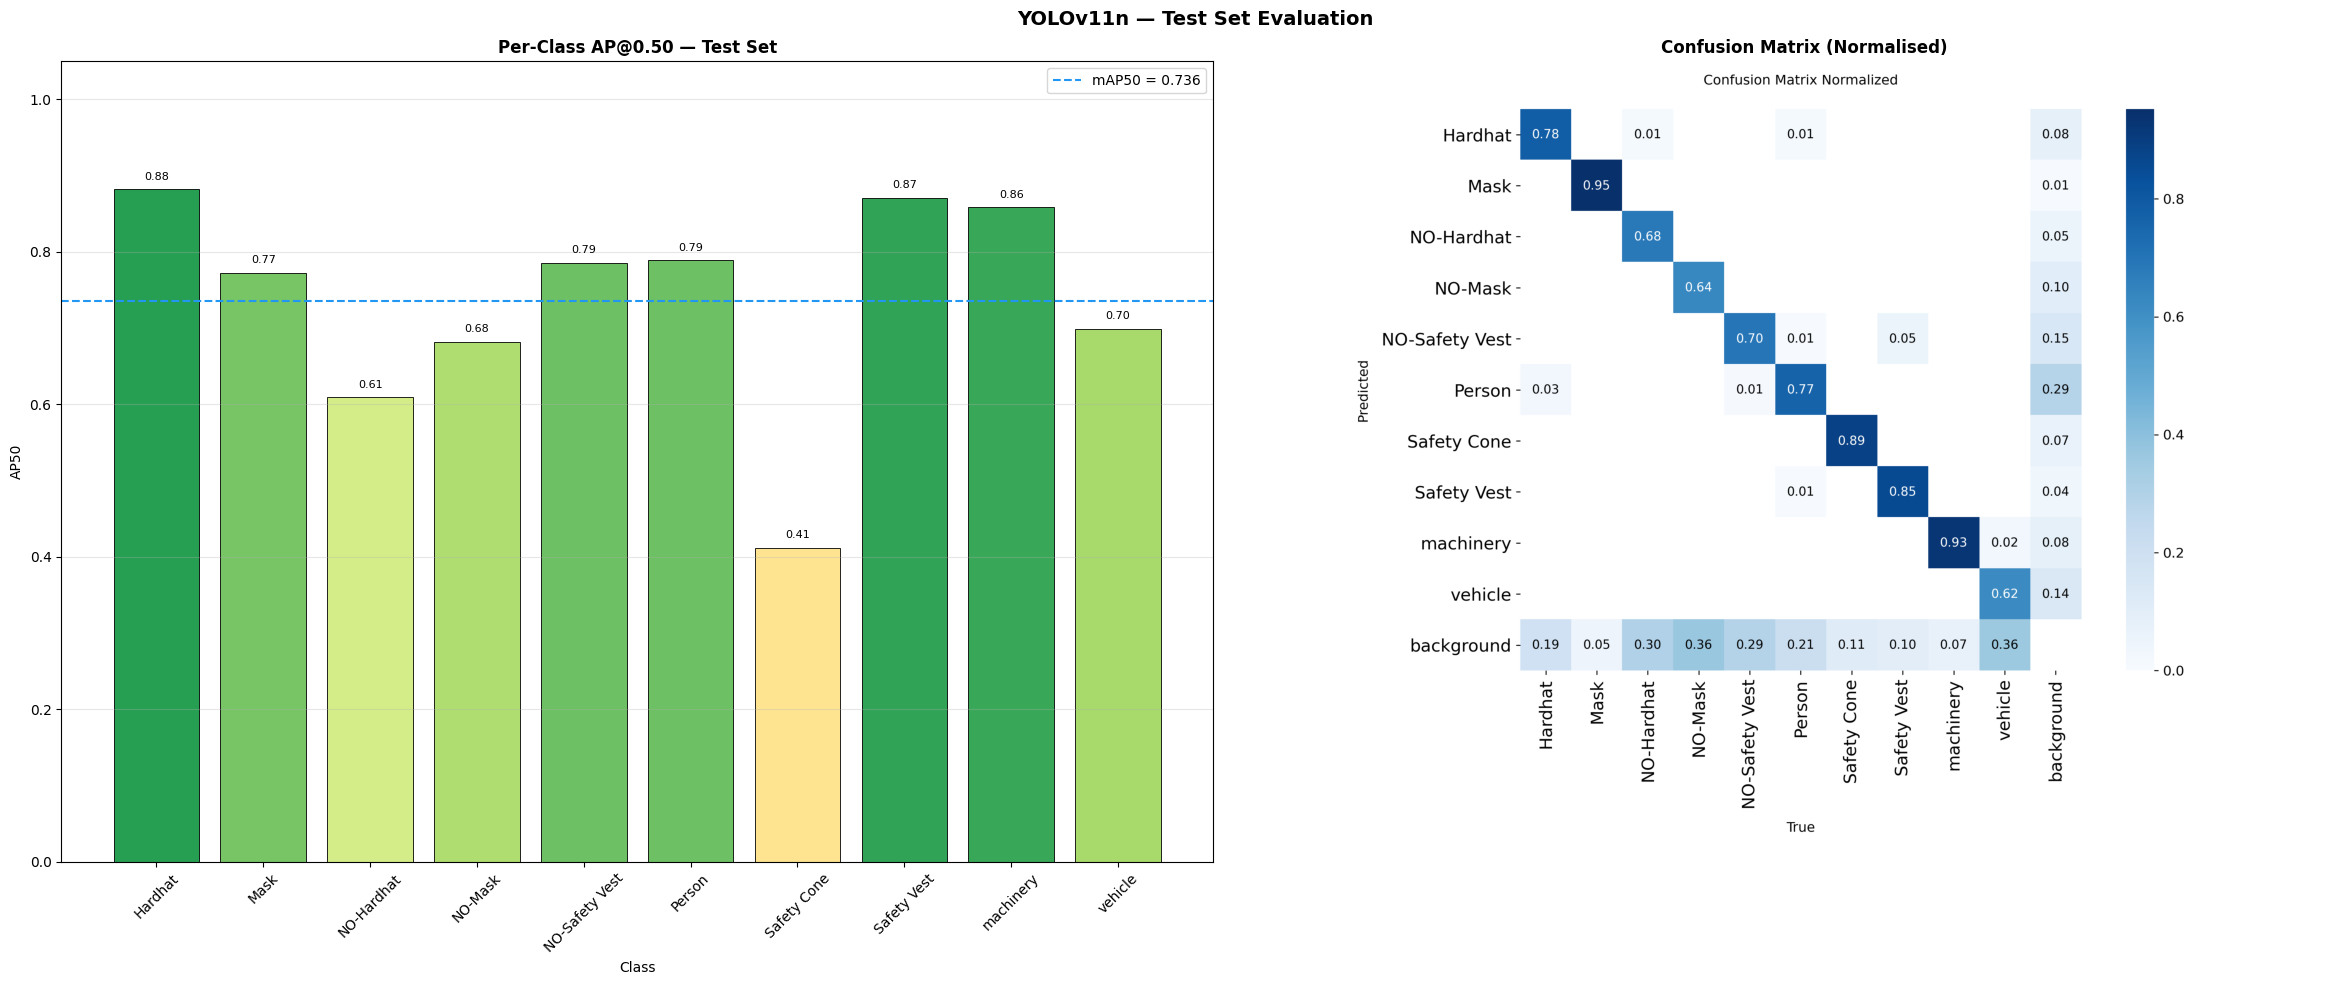

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

ap_names  = [class_names[i] for i in range(len(class_names))]
ap_values = [per_class_ap50[i] if i < len(per_class_ap50) else 0.0
              for i in range(len(class_names))]

bars = axes[0].bar(ap_names, ap_values,
                   color=[plt.cm.RdYlGn(v) for v in ap_values],
                   edgecolor="black", linewidth=0.6)
axes[0].axhline(global_map50, color="#2196F3", linestyle="--",
                linewidth=1.5, label=f"mAP50 = {global_map50:.3f}")
axes[0].set_title("Per-Class AP@0.50 — Test Set", fontweight="bold")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("AP50")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, ap_values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=8)

# Confusion matrix — read from Ultralytics-generated file
cm_path = RUN_DIR / "confusion_matrix_normalized.png"
if cm_path.exists():
    img = plt.imread(cm_path)
    axes[1].imshow(img)
    axes[1].axis("off")
    axes[1].set_title("Confusion Matrix (Normalised)", fontweight="bold")
else:
    axes[1].text(0.5, 0.5, "Confusion matrix not found", ha="center", va="center")
    axes[1].axis("off")

plt.suptitle("YOLOv11n — Test Set Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(DRIVE_DIR / "evaluation_charts_yolov11n.png", dpi=150, bbox_inches="tight")
plt.show()

10. METRICS REPORT

In [ ]:
divider = "=" * 50

lines = [
    divider,
    "  YOLOv11n PPE Compliance — Test Set Evaluation",
    divider,
    f"  Global mAP50        {global_map50:.4f}",
    f"  Global mAP50-95     {global_map50_95:.4f}",
    "",
    "  Per-Class mAP50",
    "  " + "-" * 35,
]

for idx, name in class_names.items():
    score = per_class_ap50[idx] if idx < len(per_class_ap50) else float("nan")
    lines.append(f"  {name:<28} {score:.4f}")

lines += ["", divider]
report = "\n".join(lines)

print("\n" + report)

with open(METRICS_LOG, "w") as f:
    f.write(report + "\n")

print(f"\nMetrics saved: {METRICS_LOG}")


  YOLOv11n PPE Compliance — Test Set Evaluation
  Global mAP50        0.7360
  Global mAP50-95     0.3952

  Per-Class mAP50
  -----------------------------------
  Hardhat                      0.8818
  Mask                         0.7725
  NO-Hardhat                   0.6093
  NO-Mask                      0.6816
  NO-Safety Vest               0.7856
  Person                       0.7890
  Safety Cone                  0.4120
  Safety Vest                  0.8709
  machinery                    0.8583
  vehicle                      0.6990


Metrics saved: /content/drive/MyDrive/PPE_YOLO11/yolov11n_metrics_summary.txt


11. MIGRATING TO DRIVE

In [ ]:
print("Results already saved directly to Drive:")
for f in sorted(RUN_DIR.iterdir()):
    print(f"  {f.name}")

Results already saved directly to Drive:
  BoxF1_curve.png
  BoxPR_curve.png
  BoxP_curve.png
  BoxR_curve.png
  args.yaml
  confusion_matrix.png
  confusion_matrix_normalized.png
  labels.jpg
  results.csv
  results.png
  train_batch0.jpg
  train_batch1.jpg
  train_batch2.jpg
  train_batch6520.jpg
  train_batch6521.jpg
  train_batch6522.jpg
  val_batch0_labels.jpg
  val_batch0_pred.jpg
  val_batch1_labels.jpg
  val_batch1_pred.jpg
  val_batch2_labels.jpg
  val_batch2_pred.jpg
  weights
